# Wafer Defect Data Analysis

This notebook is only for a thorough exploratory data analysis (EDA) and visualization on the wafer defect datasets (`train_data.npz` and `test_data.npz`), don't visualize the main data..

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

## 1. Data Loading

Let's load the data from `train_data.npz` and `test_data.npz`.

In [2]:
data_dir = "../data/processed"
train_path = os.path.join(data_dir, "train_data.npz")
test_path = os.path.join(data_dir, "test_data.npz")

# Load NPZ files
train_data = np.load(train_path)
test_data = np.load(test_path)

print("Train arrays:", train_data.files)
print("Test arrays:", test_data.files)

# Extract arrays
X_train, y_train = train_data["X"], train_data["y"]
X_test, y_test = test_data["X"], test_data["y"]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Convert one-hot encoded labels to 1D class indices
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)
print(f"New y_train shape: {y_train.shape}")

Train arrays: ['X', 'y']
Test arrays: ['X', 'y']
X_train shape: (26608, 52, 52), y_train shape: (26608, 8)
X_test shape: (5703, 52, 52), y_test shape: (5703, 8)
New y_train shape: (26608,)


## 2. Basic Data Integrity Checks

We check for nulls, duplicates, and general statistics.

In [3]:
def basic_checks(X, y, name="Dataset"):
    print(f"--- {name} ---")
    # Check for NaNs
    has_nans = np.isnan(X).any()
    print(f"Contains NaNs: {has_nans}")

    # Check for duplicates
    X_flat = X.reshape(X.shape[0], -1)
    unique_rows, counts = np.unique(X_flat, axis=0, return_counts=True)
    duplicates = len(X) - len(unique_rows)
    print(f"Duplicates found: {duplicates}")

    # Value range and outliers
    print(f"Value range: min={X.min()}, max={X.max()}, mean={X.mean():.4f}, std={X.std():.4f}")

    # Class distribution
    unique_classes, class_counts = np.unique(y, return_counts=True)
    print(f"Classes present: {unique_classes}")


basic_checks(X_train, y_train, "Train Data")
print("\n")
basic_checks(X_test, y_test, "Test Data")

--- Train Data ---
Contains NaNs: False
Duplicates found: 482
Value range: min=0, max=3, mean=1.0069, std=0.6933
Classes present: [0 1 2 3 4 5 6 7]


--- Test Data ---
Contains NaNs: False
Duplicates found: 26
Value range: min=0, max=3, mean=1.0062, std=0.6928
Classes present: [0 1 2 3 4 5 6 7]


## 3. Class Distribution Analysis

Understanding the balance of classes in our training and testing sets.

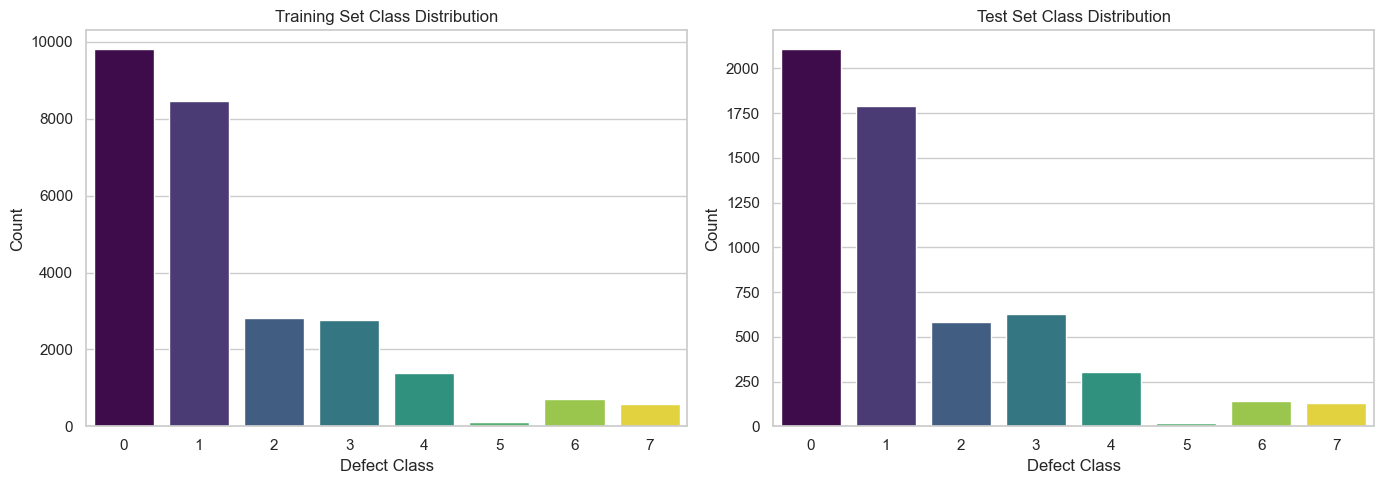

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette="viridis", 
              legend=False)
axes[0].set_title("Training Set Class Distribution")
axes[0].set_xlabel("Defect Class")
axes[0].set_ylabel("Count")

sns.countplot(x=y_test, hue=y_test, ax=axes[1], palette="viridis", 
              legend=False)
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xlabel("Defect Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 4. Spatial Data Visualization

Wafer data is spatial. We visualize samples from each class to understand the defect patterns clearly.

Visualizing Training Samples:


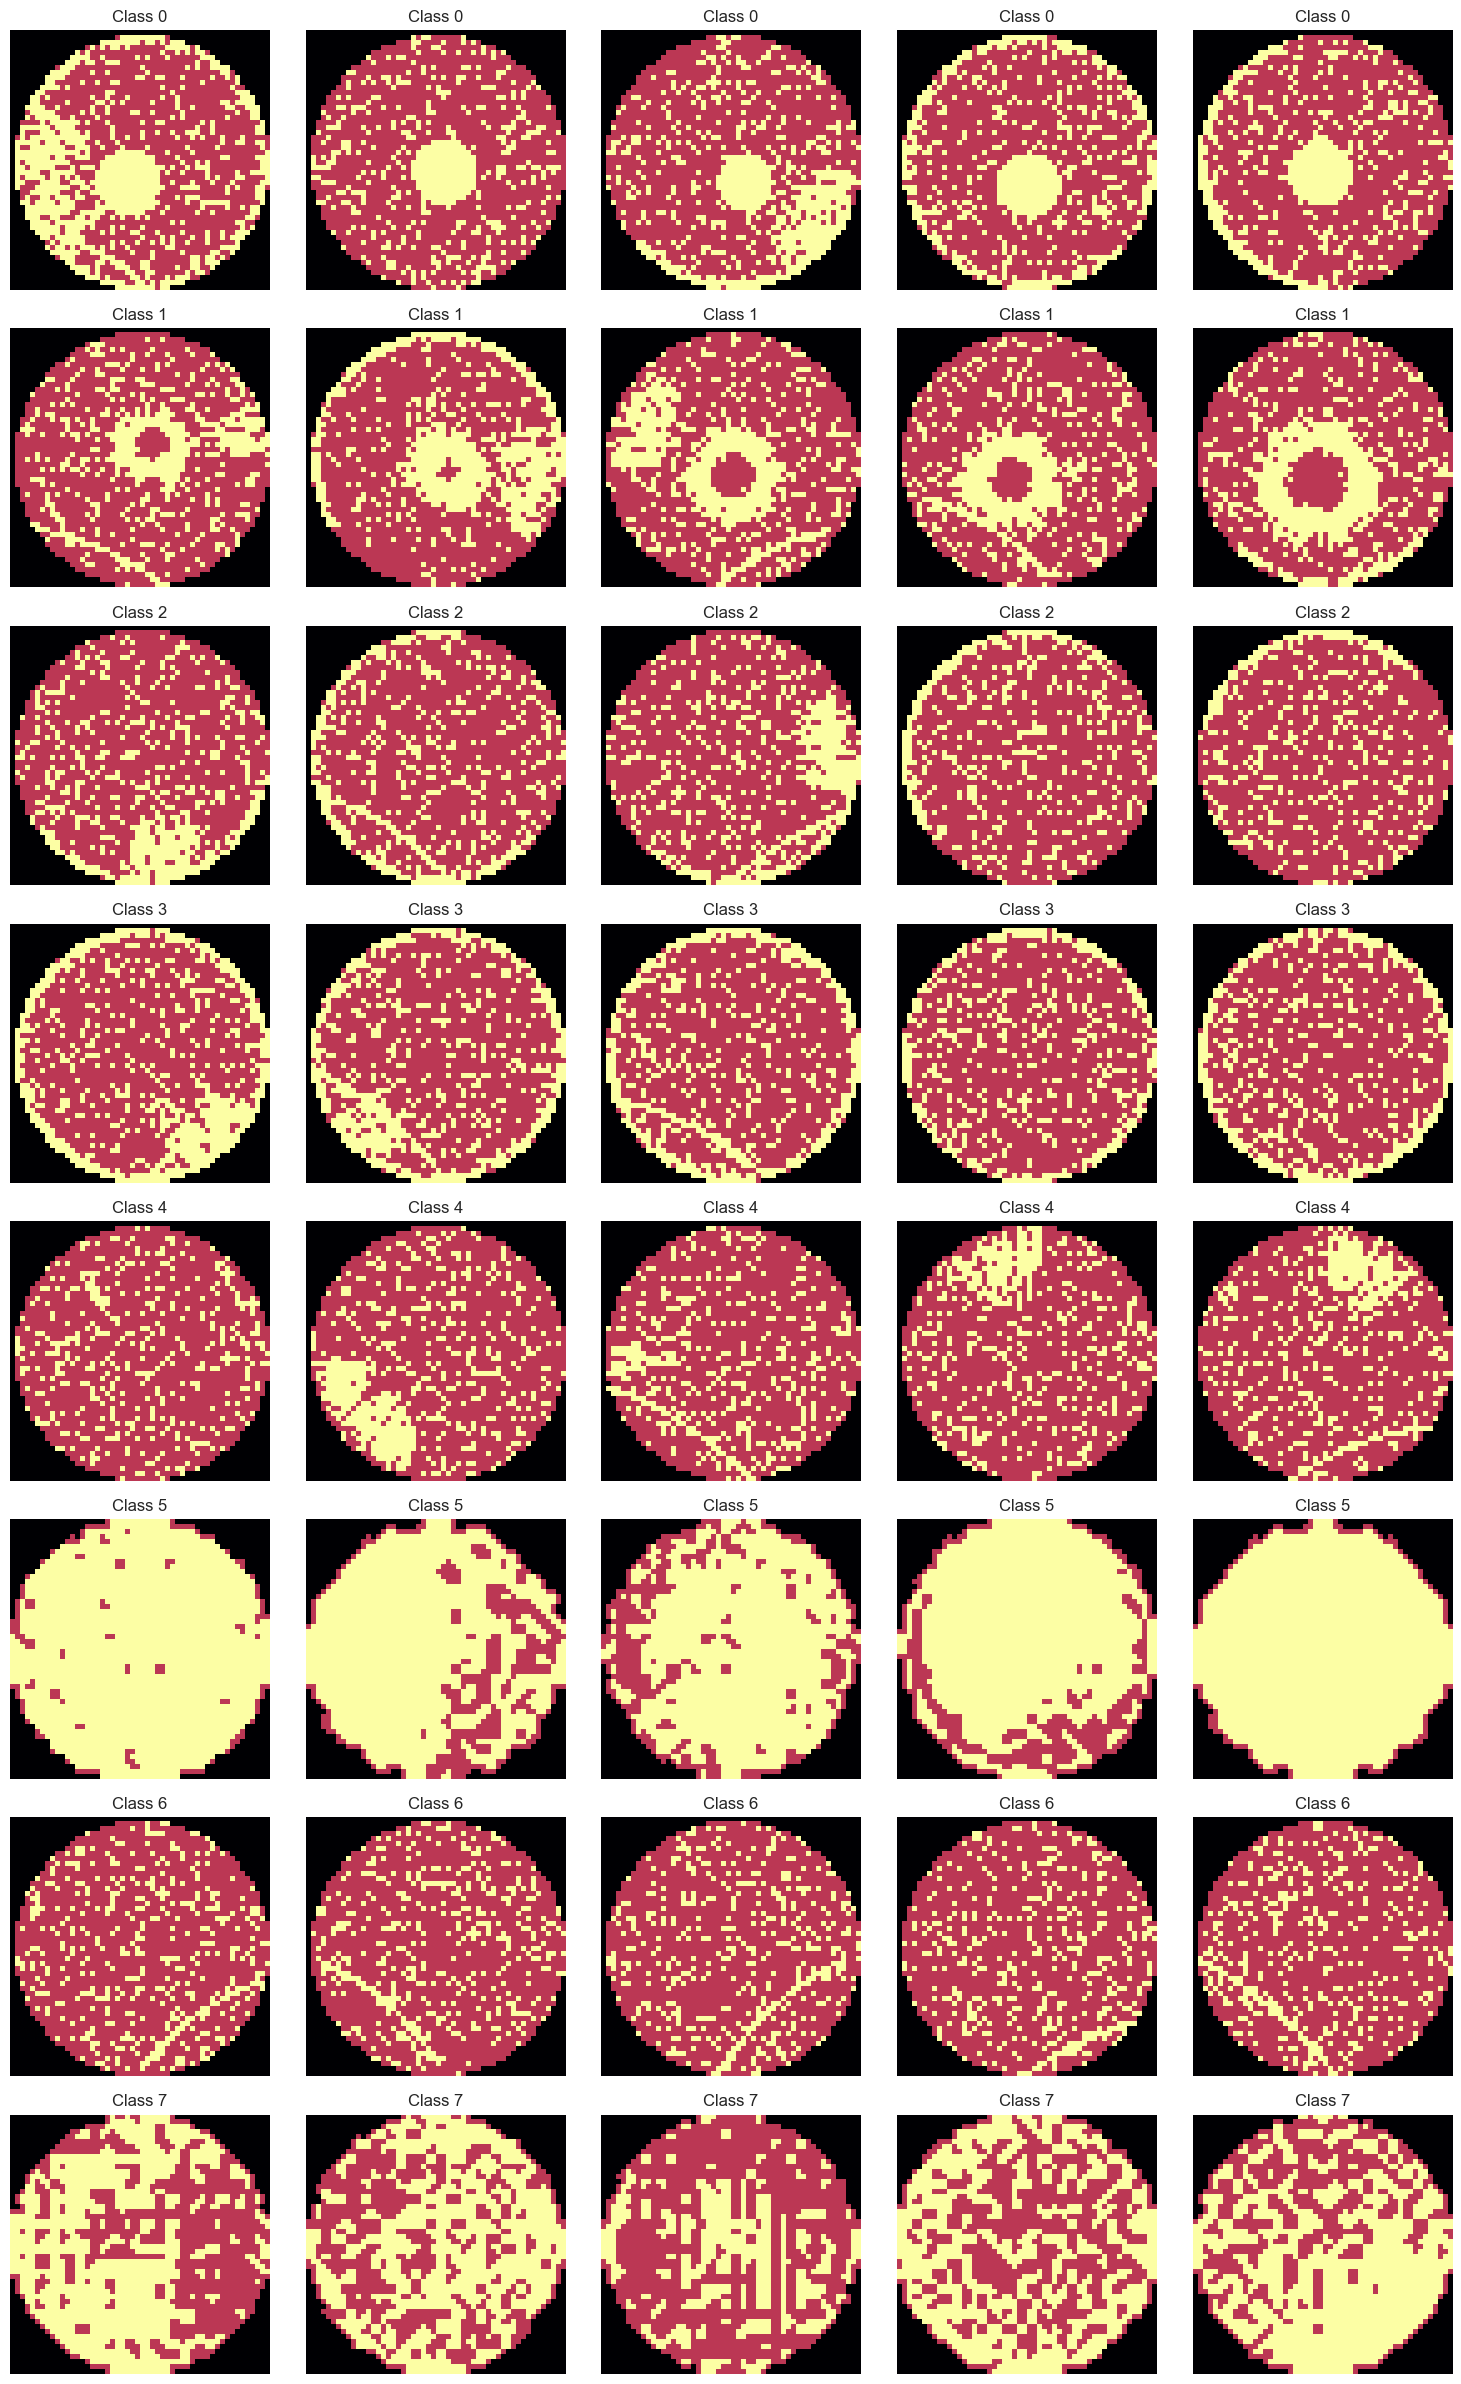

In [ ]:
def plot_wafer_samples(X, y, num_samples=3):
    unique_classes = np.unique(y)
    num_classes = len(unique_classes)

    fig, axes = plt.subplots(num_classes, num_samples, 
                             figsize=(num_samples * 3, num_classes * 3))

    for i, cls in enumerate(unique_classes):
        idx = np.where(y == cls)[0]
        sampled_idx = np.random.choice(idx, min(num_samples, len(idx)), 
                                       replace=False)

        for j, s_idx in enumerate(sampled_idx):
            ax = axes[i, j] if num_classes > 1 else axes[j]
            wafer_map = X[s_idx]

            if len(wafer_map.shape) == 3 and wafer_map.shape[-1] in [1, 3]:
                if wafer_map.shape[-1] == 1:
                    wafer_map = wafer_map[:, :, 0]
            elif len(wafer_map.shape) == 3:
                wafer_map = np.transpose(wafer_map, (1, 2, 0))
                if wafer_map.shape[-1] == 1:
                    wafer_map = wafer_map[:, :, 0]

            ax.imshow(wafer_map, cmap="inferno")
            ax.set_title(f"Class {cls}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()


print("Visualizing Training Samples:")
plot_wafer_samples(X_train, y_train, num_samples=5)

## 5. Average Spatial Heatmap per Class

By averaging all wafers of the same class, we can see the 'typical' spatial signature of that defect type.

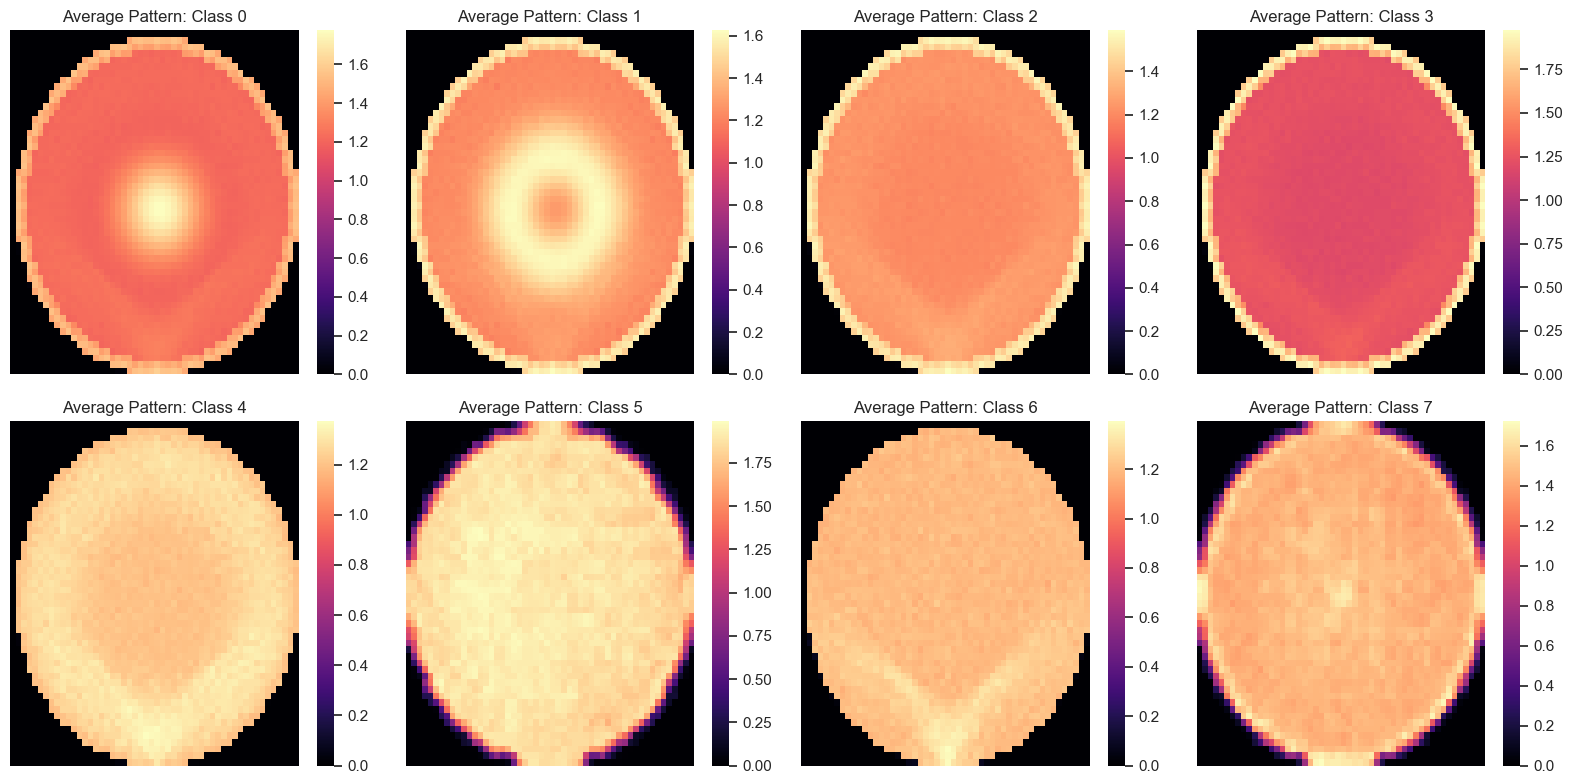

In [ ]:
def plot_average_heatmaps(X, y):
    unique_classes = np.unique(y)
    num_classes = len(unique_classes)

    cols = min(4, num_classes)
    rows = int(np.ceil(num_classes / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    if type(axes) is np.ndarray:
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, cls in enumerate(unique_classes):
        idx = np.where(y == cls)[0]
        class_wafers = X[idx]

        mean_wafer = np.mean(class_wafers, axis=0)

        if len(mean_wafer.shape) == 3:
            if mean_wafer.shape[-1] in [1, 3]:
                mean_wafer = mean_wafer[:, :, 0] if mean_wafer.shape[-1] == 1 else mean_wafer
            else:
                mean_wafer = mean_wafer[0, :, :]

        sns.heatmap(
            mean_wafer, ax=axes[i], cmap="magma", cbar=True, xticklabels=False, yticklabels=False
        )
        axes[i].set_title(f"Average Pattern: Class {cls}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


plot_average_heatmaps(X_train, y_train)

## 6. Pixel Intensity Distributions

Let's analyze the distribution of pixel values across different classes to identify outliers or anomalies.

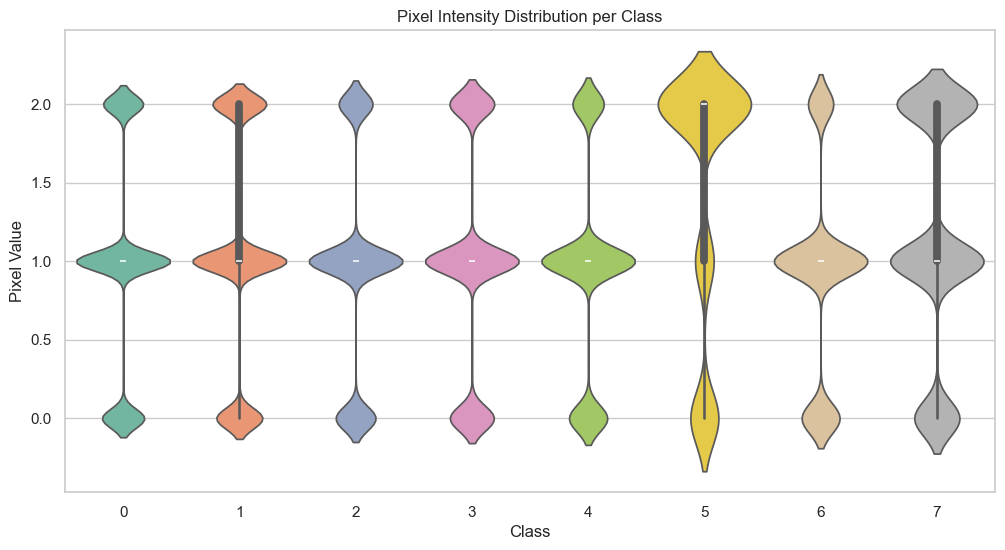

In [ ]:
plt.figure(figsize=(12, 6))
sample_size = min(5000, len(X_train))
sampled_idx = np.random.choice(len(X_train), sample_size, replace=False)

X_sample = X_train[sampled_idx]
y_sample = y_train[sampled_idx]

pixel_values = []
classes = []

for i in range(sample_size):
    flat_img = X_sample[i].flatten()
    sub_sample = np.random.choice(flat_img, min(100, len(flat_img)), replace=False)
    pixel_values.extend(sub_sample)
    classes.extend([y_sample[i]] * len(sub_sample))

df_pixels = pd.DataFrame({"Pixel Value": pixel_values, "Class": classes})

sns.violinplot(x="Class", y="Pixel Value", hue="Class", data=df_pixels, 
               palette="Set2", legend=False)
plt.title("Pixel Intensity Distribution per Class")
plt.show()

## 7. Dimensionality Reduction (PCA & t-SNE)

To see if the defect classes are separable in a lower-dimensional space, we project the high-dimensional spatial data into 2D using PCA and t-SNE.

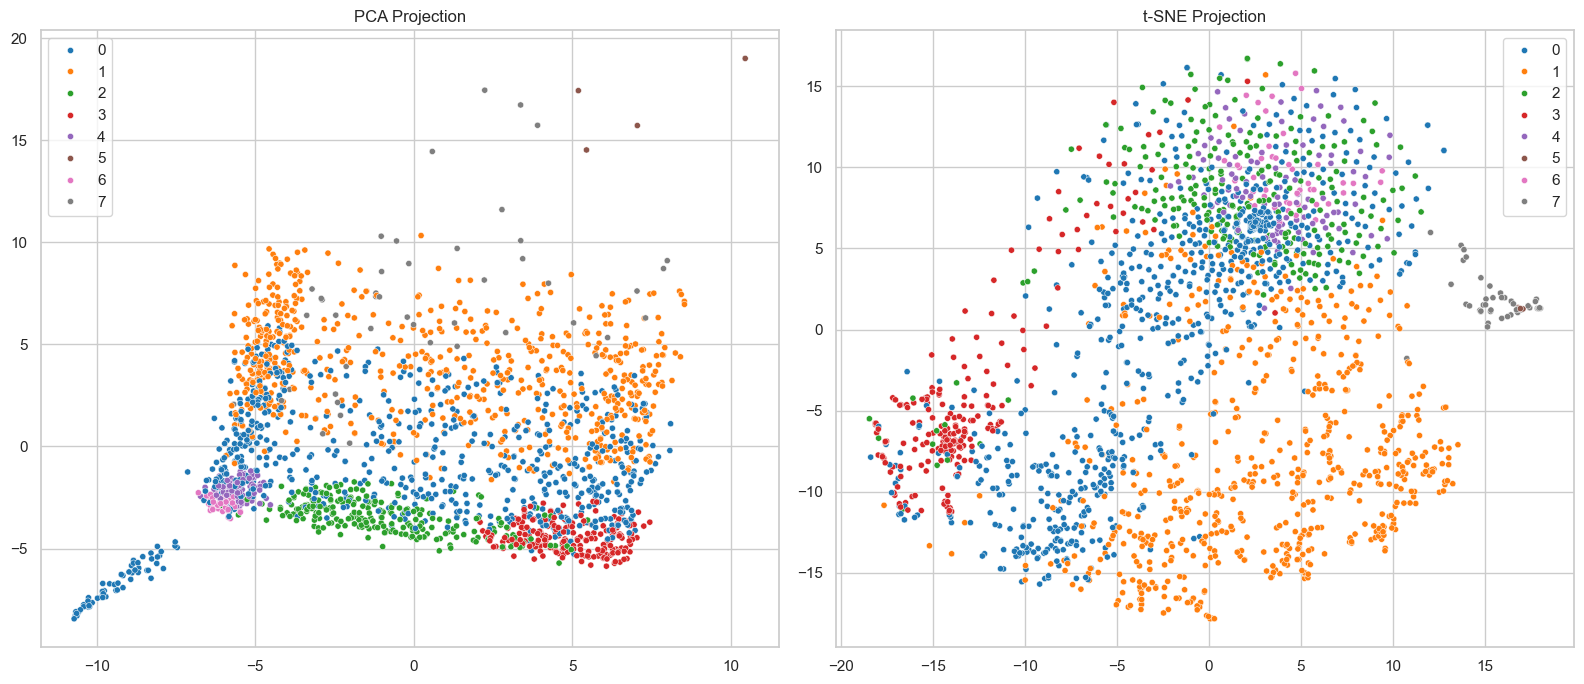

In [8]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Flatten data for PCA/t-SNE
X_flat_train = X_train.reshape(X_train.shape[0], -1)

# Sample to speed up t-SNE
tsne_sample_size = min(2000, len(X_flat_train))
idx = np.random.choice(len(X_flat_train), tsne_sample_size, replace=False)
X_tsne_sample = X_flat_train[idx]
y_tsne_sample = y_train[idx]

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tsne_sample)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_tsne_sample,
    palette="tab10",
    ax=axes[0],
    legend="full",
    s=20,
)
axes[0].set_title("PCA Projection")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y_tsne_sample,
    palette="tab10",
    ax=axes[1],
    legend="full",
    s=20,
)
axes[1].set_title("t-SNE Projection")

plt.tight_layout()
plt.show()